In [12]:
import zipfile
from pathlib import Path
from astropy.io import fits
import re
import matplotlib.pyplot as plt
import numpy as np
import pyphot
from pyphot import UnitFilter
import pandas as pd

In [13]:
def fit_lines(feh,offset=0.13):
    """Theoretical iso-metallicity lines for (CaHK-g) - bf*(g-i) vs (g-i)
    """

    Pris={}
    Pris['g_0-i_0'] = np.array([0., 0.2, 0.4, 0.6, 0.8, 1., 1.2, 1.4])
    
    #plot from theoretical curves (a bit arbitrarily offset)
    xrel = np.arange(100)*0.013 + 0.2

    if feh=='no-met':
        # for no-metal giants
        fit = 2.03002*0.488534**xrel-1.79839-0.05
    elif feh==-3.0:
        # for -3
        fit = 1.440770*0.425375**xrel-1.26330
    elif feh==-2.0:
        # for -2
        fit = 0.743684*0.164704**xrel-0.532411
    elif feh==-1.0:
        # for -1
        fit = 0.702992*0.551783**xrel-0.537230

    #Fit polynomials to the curves
    #g-i
    fit = fit+offset

    curve = np.polyfit(xrel, fit, 4)
    f_curve = np.poly1d(curve)
    x_curve = np.linspace(0.2, Pris['g_0-i_0'].max(), 50) 
    y_curve = f_curve(x_curve)

    return x_curve,y_curve

In [14]:
# Define root directories
root_filt = Path('/Users/lucakrattinger/LOCAL_FILES/synthetic/filter')
root_dir = Path('/Users/lucakrattinger/LOCAL_FILES/synthetic/AMBRE')
# Define pattern for the name to get the Temperature, log g, metallicity, alpha enrichment
pattern = re.compile(r'[a-zA-Z_]*[psPS](\d+)'r'g([0-9.]+)'r'z([-\d.]+)'r'.*?_a([-\d.]+)')
# Load CaHK filter
CaHK_filter = root_filt/'CaHK_trans.txt'
wl_cahk, tx_cahk =  np.loadtxt(CaHK_filter, usecols=(0, 2), unpack=True)

In [15]:
# Gaia 
# Import filters
Gaia_g = root_filt/'GAIA_GAIA3.G.dat'
Gaia_BP = root_filt/'GAIA_GAIA3.Gbp.dat'
gaia_RP = root_filt/'GAIA_GAIA3.Grp.dat'

# Load filter transmission data
wl_gG, tx_gG =np.loadtxt(Gaia_g, unpack=True)
wl_bpG, tx_bpG = np.loadtxt(Gaia_BP, unpack=True)
wl_rpG, tx_rpG = np.loadtxt(gaia_RP, unpack=True)

# SDSS
# Import filters
SDSS_g = root_filt/'SLOAN_SDSS.g.dat'
SDSS_i = root_filt/'SLOAN_SDSS.i.dat'
SDSS_r = root_filt/'SLOAN_SDSS.r.dat'

# Load filter transmission data
wl_gS, tx_gS =np.loadtxt(SDSS_g, unpack=True)
wl_iS, tx_iS = np.loadtxt(SDSS_i, unpack=True)
wl_rS, tx_rS = np.loadtxt(SDSS_r, unpack=True)
    
# PS1
# Import filters
PS1_g = root_filt/'PAN-STARRS_PS1.g.dat'
PS1_i = root_filt/'PAN-STARRS_PS1.i.dat'
PS1_r = root_filt/'PAN-STARRS_PS1.r.dat'

# Load filter transmission data
wl_gP, tx_gP =np.loadtxt(PS1_g, unpack=True)
wl_iP, tx_iP = np.loadtxt(PS1_i, unpack=True)
wl_rP, tx_rP = np.loadtxt(PS1_r, unpack=True)



In [5]:
# Define filters and zeropoints based on photometry

zeropoint_Ca = 6.96645e-9
teff_list, logg_list, feh_list, alpha_list = [], [], [], []
f_cahk = UnitFilter(wl_cahk, tx_cahk, name='my_CaHK', unit='AA', dtype='photon')

# Gaia

f_gG = UnitFilter(wl_gG, tx_gG, name='my_g', unit='AA', dtype='photon')
f_bpG = UnitFilter(wl_bpG, tx_bpG, name='my_bp', unit='AA', dtype='photon')
f_rpG = UnitFilter(wl_rpG, tx_rpG, name='my_rp', unit='AA', dtype='photon')

zeropoint_gG = 2.81581e-9
zeropoint_bpG = 4.16921e-9
zeropoint_rpG = 1.80349e-9

g_listG = []
bprp_listG = []
CaHKg_listG = []

# SDSS

f_gS = UnitFilter(wl_gS, tx_gS, name='my_g', unit='AA', dtype='photon')
f_rS = UnitFilter(wl_rS, tx_rS, name='my_r', unit='AA', dtype='photon')
f_iS = UnitFilter(wl_iS, tx_iS, name='my_i', unit='AA', dtype='photon')

zeropoint_gS = 4.92255e-9	
zeropoint_iS = 1.94038e-9	
zeropoint_rS = 2.85425e-9	

gi_listS = []
gr_listS = []
CaHKg_listS = []

# PS1

f_gP = UnitFilter(wl_gP, tx_gP, name='my_g', unit='AA', dtype='photon')
f_rP = UnitFilter(wl_rP, tx_rP, name='my_r', unit='AA', dtype='photon')
f_iP = UnitFilter(wl_iP, tx_iP, name='my_i', unit='AA', dtype='photon')

zeropoint_gP = 4.62937e-9	
zeropoint_iP = 1.91728e-9	
zeropoint_rP = 2.83071e-9

gi_listP = []
gr_listP = []
CaHKg_listP = []

In [ ]:
nb_spectra = 0

# Iterate over all zip files and calculate magnitudes based on photometry


for outer_zip in root_dir.glob('*.zip'):
    print(f"Processing outer ZIP: {outer_zip.name}")
    
    with zipfile.ZipFile(outer_zip, 'r') as outer:
        for inner_name in outer.namelist():
            if not inner_name.endswith('.zip'):
                continue
            
            with outer.open(inner_name) as inner_zip_bytes:
                with zipfile.ZipFile(inner_zip_bytes) as inner:
                    for fits_name in inner.namelist():
                        fits_name = fits_name.strip()
                        if not fits_name.endswith('.FITS'):
                            continue
                        
                        with inner.open(fits_name) as f:
                            # Get spectrum and wavelength
                            hdul = fits.open(f)
                            table = hdul[1].data  
                            wavelength = table['wavelength']
                            flux = table['flux']

                            # CaHK filter
                            flux_cahk = f_cahk.get_flux(wavelength, flux, axis=1)
                            mag_cahk =  -2.5 * np.log10(flux_cahk.magnitude / zeropoint_Ca)
                            

                            # Gaia
                            flux_gG = f_gG.get_flux(wavelength, flux, axis=1)
                            flux_bpG = f_bpG.get_flux(wavelength, flux, axis=1)
                            flux_rpG = f_rpG.get_flux(wavelength, flux, axis=1)

                            mag_gG = -2.5 * np.log10(flux_gG.magnitude / zeropoint_gG)
                            mag_bpG =  -2.5 * np.log10(flux_bpG.magnitude / zeropoint_bpG)
                            mag_rpG =  -2.5 * np.log10(flux_rpG.magnitude / zeropoint_rpG)
                            

                            gG = mag_gG
                            bprpG = mag_bpG - mag_rpG
                            CaHKgG = mag_cahk - mag_gG

                            #add to list
                            g_listG.append(gG)
                            bprp_listG.append(bprpG)
                            CaHKg_listG.append(CaHKgG)

                            # SDSS
                            flux_gS = f_gS.get_flux(wavelength, flux, axis=1)
                            flux_iS = f_iS.get_flux(wavelength, flux, axis=1)
                            flux_rS = f_rS.get_flux(wavelength, flux, axis=1)

                            mag_gS = -2.5 * np.log10(flux_gS.magnitude / zeropoint_gS)
                            mag_iS =  -2.5 * np.log10(flux_iS.magnitude / zeropoint_iS)
                            mag_rS =  -2.5 * np.log10(flux_rS.magnitude / zeropoint_rS)

                            giS = mag_gS - mag_iS
                            grS = mag_gS - mag_rS
                            CaHKgS = mag_cahk - mag_gS

                            #add to list
                            gi_listS.append(giS)
                            gr_listS.append(grS)
                            CaHKg_listS.append(CaHKgS)


                            # PS1
                            flux_gP = f_gP.get_flux(wavelength, flux, axis=1)
                            flux_iP = f_iP.get_flux(wavelength, flux, axis=1)
                            flux_rP = f_rP.get_flux(wavelength, flux, axis=1)

                            print("FLUX =",flux_gP)
                            print("mag =",flux_gP.magnitude)

                            mag_gP = -2.5 * np.log10(flux_gP.magnitude / zeropoint_gP)
                            mag_iP =  -2.5 * np.log10(flux_iP.magnitude / zeropoint_iP)
                            mag_rP =  -2.5 * np.log10(flux_rP.magnitude / zeropoint_rP)

                            giP = mag_gP - mag_iP
                            grP = mag_gP - mag_rP
                            CaHKgP = mag_cahk - mag_gP

                            #add to list
                            gi_listP.append(giP)
                            gr_listP.append(grP)
                            CaHKg_listP.append(CaHKgP)


                            hdul.close()
                        match = pattern.search(fits_name)
                        if match:
                            nb_spectra += 1
                            # Get temperature from the name
                            teff_list.append(float(match.group(1)))
                            # Get log g from the name
                            logg_list.append(float(match.group(2)))
                            # Get metallicity from the name
                            feh_list.append(float(match.group(3)))
                            # Get alpha from the name
                            alpha_list.append(float(match.group(4)))
                        else:
                            print("Skipped FITS with unexpected name:", fits_name)



print("Spectra with extracted stellar parameters:", nb_spectra)

Processing outer ZIP: AMBRE_-5.0.zip
FLUX = 1898142.5139243382 erg / angstrom * centimeter ** 2 * second
mag = 1898142.5139243382
FLUX = 1898028.198532211 erg / angstrom * centimeter ** 2 * second
mag = 1898028.198532211
FLUX = 1897873.4036593535 erg / angstrom * centimeter ** 2 * second
mag = 1897873.4036593535
FLUX = 1910436.5796794193 erg / angstrom * centimeter ** 2 * second
mag = 1910436.5796794193
FLUX = 1910318.462624542 erg / angstrom * centimeter ** 2 * second
mag = 1910318.462624542
FLUX = 1910154.4811899858 erg / angstrom * centimeter ** 2 * second
mag = 1910154.4811899858
FLUX = 1923155.0034587008 erg / angstrom * centimeter ** 2 * second
mag = 1923155.0034587008
FLUX = 1923026.757610215 erg / angstrom * centimeter ** 2 * second
mag = 1923026.757610215
FLUX = 1922843.2259270712 erg / angstrom * centimeter ** 2 * second
mag = 1922843.2259270712
FLUX = 2721735.190828769 erg / angstrom * centimeter ** 2 * second
mag = 2721735.190828769
FLUX = 2721618.3975683013 erg / angstrom 

KeyboardInterrupt: 

In [ ]:
# save lists to avoid recalculating
#data = {
    'feh': feh_list,
    'logg' : logg_list,
    'teff': teff_list,
    'alpha': alpha_list,
    
    # Gaia
    'gG': g_listG,
    'bprpG': bprp_listG,
    'CaHKgG': CaHKg_listG,
    
    # SDSS
    'giS': gi_listS,
    'grS': gr_listS,
    'CaHKgS': CaHKg_listS,
    
    # PS1
    'giP': gi_listP,
    'grP': gr_listP,
    'CaHKgP': CaHKg_listP
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Save to a Parquet file 
output_file = 'calculated_magnitudes.parquet'
#df.to_parquet(output_file)

print(f"Data saved successfully to {output_file}")

Data saved successfully to calculated_magnitudes.parquet


In [16]:
# load saved data
df = pd.read_parquet('/Users/lucakrattinger/Documents/MA1-EPFL/TP4/code/calculated_magnitudes.parquet')
feh_list = df['feh'].tolist()
logg_list = df['logg'].tolist()
alpha_list = df['alpha'].tolist()
teff_list = df['teff'].tolist()
    
# Gaia
g_listG = df['gG'].tolist()
bprp_listG = df['bprpG'].tolist()
CaHKg_listG = df['CaHKgG'].tolist()

# SDSS
gi_listS = df['giS'].tolist()
gr_listS = df['grS'].tolist()
CaHKg_listS = df['CaHKgS'].tolist()

# PS1
gi_listP = df['giP'].tolist()
gr_listP = df['grP'].tolist()
CaHKg_listP = df['CaHKgP'].tolist()


<>:34: SyntaxWarning: invalid escape sequence '\c'
<>:63: SyntaxWarning: invalid escape sequence '\c'
<>:69: SyntaxWarning: invalid escape sequence '\c'
<>:100: SyntaxWarning: invalid escape sequence '\c'
<>:106: SyntaxWarning: invalid escape sequence '\c'
<>:34: SyntaxWarning: invalid escape sequence '\c'
<>:63: SyntaxWarning: invalid escape sequence '\c'
<>:69: SyntaxWarning: invalid escape sequence '\c'
<>:100: SyntaxWarning: invalid escape sequence '\c'
<>:106: SyntaxWarning: invalid escape sequence '\c'
/var/folders/zt/ylf2qf8x2d5dr9ph82k39mr80000gn/T/ipykernel_43478/2381674627.py:34: SyntaxWarning: invalid escape sequence '\c'
  ylabel = f'(CaHK - G) - {bf} $\cdot$ (BP - RP)'
/var/folders/zt/ylf2qf8x2d5dr9ph82k39mr80000gn/T/ipykernel_43478/2381674627.py:63: SyntaxWarning: invalid escape sequence '\c'
  ylabel = f'(CaHK - g) - {bf} $\cdot$ ({color})'
/var/folders/zt/ylf2qf8x2d5dr9ph82k39mr80000gn/T/ipykernel_43478/2381674627.py:69: SyntaxWarning: invalid escape sequence '\c'
  yla

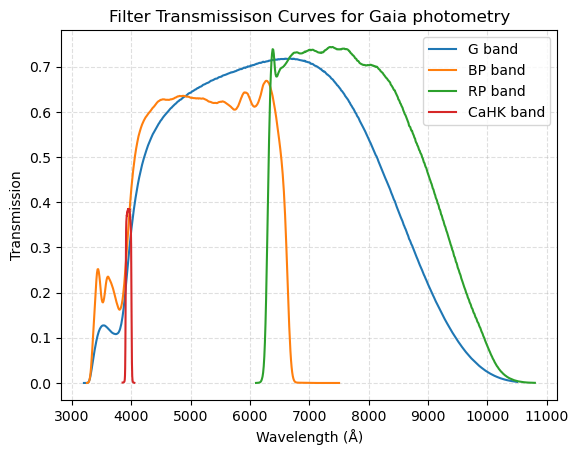

/var/folders/zt/ylf2qf8x2d5dr9ph82k39mr80000gn/T/ipykernel_43478/2381674627.py:139: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


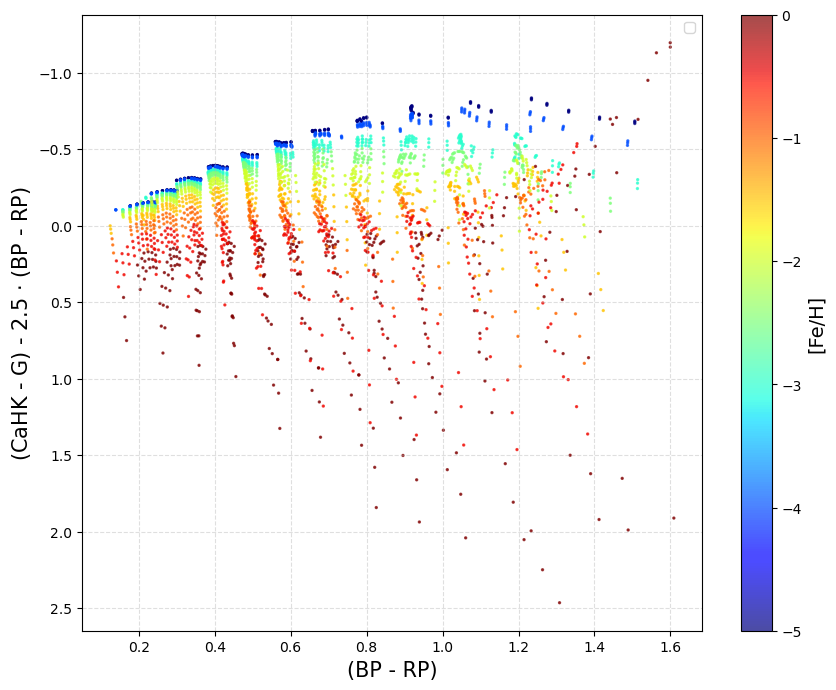

In [31]:
# Convert to np array
feh = np.array(feh_list)
logg = np.array(logg_list)
alpha = np.array(alpha_list)
teff = np.array(teff_list)

# Plot filters and pseudo color-color diagram for the desired photometry
photometry = input("Enter photmetry name (Gaia, SDSS, PS1): ")
if not photometry in ['Gaia', 'SDSS', 'PS1']:
    raise ValueError("Invalid photometry name. Please enter 'Gaia', 'SDSS', or 'PS1'.")

# Plot for Gaia
if photometry == 'Gaia':
    color = 'o'
    # Plot filters 
    plt.plot(wl_gG, tx_gG, label ='G band')
    plt.plot(wl_bpG, tx_bpG, label ='BP band')
    plt.plot(wl_rpG, tx_rpG, label ='RP band')
    plt.plot(wl_cahk, tx_cahk, label ='CaHK band')
    plt.xlabel('Wavelength (Å)')
    plt.ylabel('Transmission')
    plt.title(f'Filter Transmissison Curves for {photometry} photometry')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend()
    plt.show()

    # Plot pseudo-color diagram
    G = np.array(g_listG)
    bprp = np.array(bprp_listG)
    bf = 2.5
    x_axis = bprp
    y_axis = np.array(CaHKg_listG-bf*(bprp))
    xlabel = '(BP - RP)'
    ylabel = f'(CaHK - G) - {bf} $\cdot$ (BP - RP)'

# Plot for SDSS
elif photometry == 'SDSS':
    # Plot filters
    plt.plot(wl_gS, tx_gS, label ='g band')
    plt.plot(wl_iS, tx_iS, label ='i band')
    plt.plot(wl_rS, tx_rS, label ='r band')
    plt.plot(wl_cahk, tx_cahk, label ='CaHK band')

    plt.xlabel('Wavelength (Å)')
    plt.ylabel('Transmission')
    plt.title(f'Filter Transmissison Curves for {photometry} photometry')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend()
    plt.show()

    giS = np.array(gi_listS)
    grS = np.array(gr_listS)

    # Choose color index
    color = input("Enter color index to use (g-i/g-r):")
    if not color in ['g-i','g-r']:
        raise ValueError("Color must be one of 'g-i' or 'g-r'")
    if color == 'g-i':
        bf = 1.5
        x_axis = giS
        y_axis = np.array(CaHKg_listS-bf*giS)
        xlabel = f'({color})'
        ylabel = f'(CaHK - g) - {bf} $\cdot$ ({color})'
    elif color == 'g-r':
        bf = 2
        x_axis = grS
        y_axis = np.array(CaHKg_listS-bf*grS)
        xlabel = f'({color})'
        ylabel = f'(CaHK - g) - {bf} $\cdot$ ({color})'
    else:
        raise ValueError("Color index must be 'g-i' or 'g-r'")
    
# Plot for PS1
elif photometry == 'PS1':
    # Plot filters
    plt.plot(wl_gP, tx_gP, label ='g band')
    plt.plot(wl_iP, tx_iP, label ='i band')
    plt.plot(wl_rP, tx_rP, label ='r band')

    plt.plot(wl_cahk, tx_cahk, label ='CaHK band')
    plt.xlabel('Wavelength (Å)')
    plt.ylabel('Transmission')
    plt.title(f'Filter Transmissison Curves for {photometry} photometry')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend()
    plt.show()

    gi = np.array(gi_listP)
    gr = np.array(gr_listP)

    # Choose color index
    color = input("Enter color index to use (g-i/g-r):")
    if not color in ['g-i','g-r']:
        raise ValueError("Color must be one of 'g-i' or 'g-r'")
    if color == 'g-i':
        bf = 1.65
        x_axis = gi
        y_axis = np.array(CaHKg_listP-bf*gi)
        xlabel = f'({color})'
        ylabel = f'(CaHK - g) - {bf} $\cdot$ ({color})'
    elif color == 'g-r':
        bf = 2.4
        x_axis = gr
        y_axis = np.array(CaHKg_listP-bf*gr)
        xlabel = f'({color})'
        ylabel = f'(CaHK - g) - {bf} $\cdot$ ({color})'
    else:
        raise ValueError("Color index must be 'g-i' or 'g-r'")
    

# plot pseudo-color diagrams 
plt.figure(figsize=(10,8))
sc = plt.scatter(x_axis,y_axis, c=feh_list, cmap='jet', s=2, alpha=0.7)
plt.gca().invert_yaxis()
plt.xlabel(xlabel,fontsize=15)
plt.ylabel(ylabel,fontsize=15)
#plt.title(f'Pseudo color-color diagram for {photometry} photometry ',fontsize=18)
cbar = plt.colorbar(label='[Fe/H]')
cbar.set_label(label='[Fe/H]', fontsize=14)

# Set axis limit for g-i and g-r
if color == 'g-i' or color == 'g-r':
    plt.xlim(0,1.5)
    plt.ylim(0.1,-1.2)
plt.grid(True, linestyle='--', alpha=0.4)

# Plot theoretical lines if g-i
if color == 'g-i':
    # Plot theoretical lines
    x,y = fit_lines(-3,0)
    x1,y1 = fit_lines(-2,0)
    x2,y2 = fit_lines(-1,0)
    x3,y3 = fit_lines('no-met',0)
    plt.plot(x3,y3,c='black', label='no metals')
    plt.plot(x2,y2,c='orange', label='[Fe/H]=-1')
    plt.plot(x1,y1, c='yellow', label='[Fe/H]=-2')
    plt.plot(x,y,c='cyan', label='[Fe/H]=-3')

plt.legend()
plt.savefig('PS1g-r.svg', format='svg', bbox_inches='tight')
plt.show()

In [ ]:
df_new = pd.DataFrame({
    'metallicity': feh,
    'g_minus_r': gr_listS,
    'g_minus_i': gi_listS,
    'CaHK_minus_g' : np.array(CaHKg_listS)
})
df_new.head()
df_met3 = df_new[df_new["metallicity"] == -3]
df_met4 = df_new[df_new["metallicity"] == -4]
